In [13]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState

import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()


True

In [3]:
# Section 2 — Document Loading
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()

print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [4]:
# Section 3 — Text Chunking
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [5]:
# Section 4 — Embedding Model
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [6]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_conditional",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("Vector store ready")

Vector store ready


In [7]:
llm = ChatOpenAI(model="gpt-5-mini")        # route_question and generate

agent_llm = ChatOpenAI(model="gpt-5-mini")  # agent node; tools bound later


In [8]:
# define the state of graph.
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool


In [9]:
class RouteDecision(BaseModel):

    needs_retrieval: bool

In [11]:
# define the two tools 
# 1. knowledeg base tool.
# 2. web-serach tool.

@tool(response_format="content_and_artifact")
def vector_store_search(query : str, k: int = 3):

    """
    Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages.
    """

    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(query)

    context = "\n\n ## Vector Store Result" + "\n\n".join(d.page_content for d in docs)

    return context, docs


@tool(response_format="content_and_artifact")
def web_search(query : str, max_results: int = 3):
    """ 
    search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned.
    """

    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]

    context = "\n\n ## Web Search Results" + "\n\n".join(d.page_content for d in docs)

    return context, docs


In [12]:
# now we are going to bind the tool and creatre langraph tool node

tools = [vector_store_search, web_search]
agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [14]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})

    return {"needs_retrieval": decision.needs_retrieval}

In [15]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)



def agent(state: AgenticRAGState) -> dict:

    messages = state['messages']

    if not messages:
        messages = [
            SystemMessage(content = AGENT_SYSTEM_PROMPT),
            HumanMessage(content=state['query'])
        ]

    response = agent_llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [16]:
#  collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    tool_messages = [m for m in state['messages'] if isinstance(m, ToolMessage)]


    all_docs, context_parts = [], []

    for msg in tool_messages:
        context_parts.append(msg.content)
        all_docs.append(msg.artifact)


    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs
    }

In [17]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [18]:
def route_after_classification(state: AgenticRAGState) -> Literal['agent', 'generate']:

    if state['needs_retrieval']:
        return "agent"
    return "generate"


def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    if state['messages'][-1].tool_calls:
        return "tools"
    return "collect_tool_output"

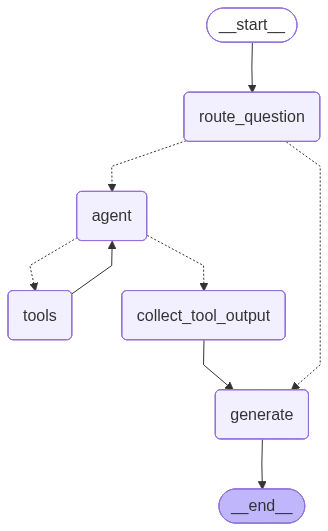

In [21]:
# define the stateGraph:

graph_builder = StateGraph(AgenticRAGState)

# add node
graph_builder.add_node('route_question', route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node('generate', generate)


# add edge 

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges('route_question', route_after_classification)
graph_builder.add_conditional_edges('agent', route_after_agent)
graph_builder.add_edge('tools', "agent")
graph_builder.add_edge('collect_tool_output', 'generate')
graph_builder.add_edge('generate', END)


graph = graph_builder.compile()
graph









In [ ]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": ""})

In [ ]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval : {result_vs['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

In [ ]:
print(result_vs["context"])



In [ ]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": ""})

In [ ]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval : {result_web['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

In [ ]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand and also tell me about the weather in mumbai"

result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": ""})

In [ ]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval : {result_both['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")

In [ ]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": ""})

In [ ]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval : {result_none['needs_retrieval']}")
print(f"retrieved_docs  : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")